# CNN18 Binary Segmentation (No Skip Connections)

This notebook keeps the same ResNet18-style stage layout as the baseline but removes residual additions inside blocks.

Goal: isolate the effect of skip connections on binary semantic segmentation training dynamics.

In [ ]:
import os
import json
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [2]:
# ------------------------------
# Config
# ------------------------------
SEED = 42
IMG_SIZE = 256
BATCH_SIZE = 8
NUM_EPOCHS = 20
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0
THRESHOLD = 0.5

MEAN_LIST = [0.485, 0.456, 0.406]
STD_LIST = [0.229, 0.224, 0.225]
MEAN_T = torch.tensor(MEAN_LIST).view(3, 1, 1)
STD_T = torch.tensor(STD_LIST).view(3, 1, 1)

DATA_ROOT = Path("../dataset/EDAM 13 data/data")
OUTPUT_ROOT = Path("outputs/cnn18_no_skip_seg")
LOG_DIR = OUTPUT_ROOT / "logs"
MODEL_DIR = OUTPUT_ROOT / "models"
PLOT_DIR = OUTPUT_ROOT / "plots"
for path in [LOG_DIR, MODEL_DIR, PLOT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Data root: {DATA_ROOT.resolve()}")
print(f"Output root: {OUTPUT_ROOT.resolve()}")

Data root: C:\Users\DELL\Projects\DL\Resnet\Segmentation\dataset\EDAM 13 data\data
Output root: C:\Users\DELL\Projects\DL\Resnet\Segmentation\Resnet 18\outputs\cnn18_no_skip_seg


Train samples: 1531 | Valid samples: 202
Test samples: 202


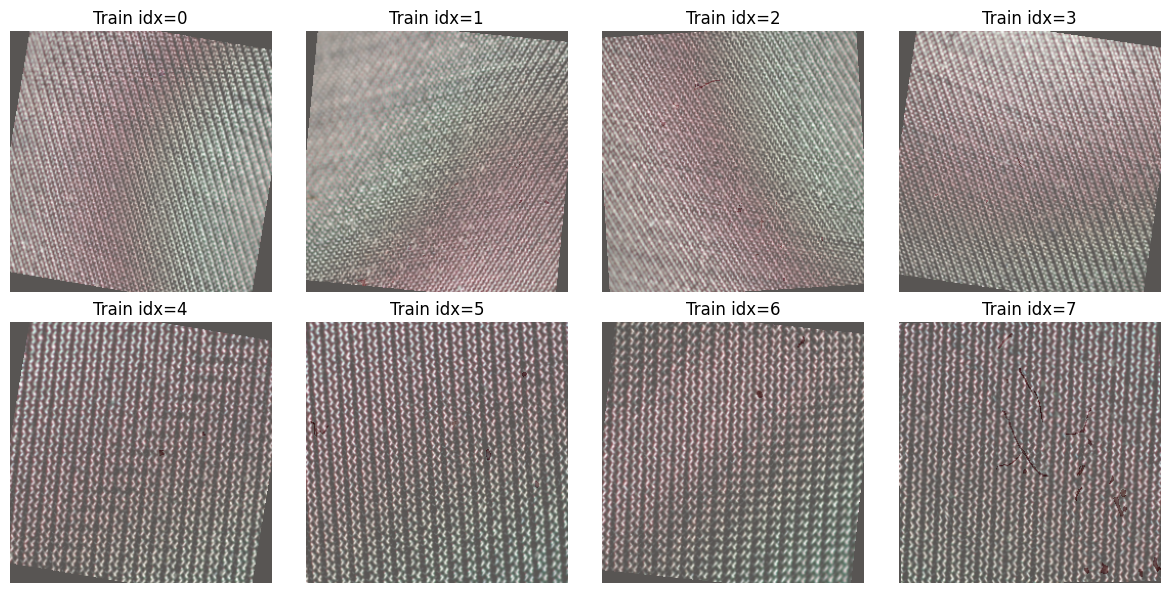

Saved dataset preview: outputs\cnn18_no_skip_seg\plots\dataset_preview.png


In [3]:
class EDAMBinarySegmentationDataset(Dataset):
    SPLIT_MAP = {
        "train": ("0_train", "0_train_bi"),
        "valid": ("1_valid", "1_valid_bi"),
        "test": ("2_test", "2_test_bi"),
    }

    def __init__(self, root: Path, split: str, img_size: int = 256, augment: bool = False):
        if split not in self.SPLIT_MAP:
            raise ValueError(f"Unsupported split: {split}")

        self.root = Path(root)
        self.split = split
        self.img_size = img_size
        self.augment = augment

        image_folder, mask_folder = self.SPLIT_MAP[split]
        self.image_dir = self.root / image_folder
        self.mask_dir = self.root / mask_folder

        image_files = sorted(self.image_dir.glob("*.jpg"))
        self.samples = []
        for image_path in image_files:
            mask_path = self.mask_dir / image_path.name
            if mask_path.exists():
                self.samples.append((image_path, mask_path))

        if len(self.samples) == 0:
            raise RuntimeError(f"No paired samples found for split={split} in {self.image_dir}")

    def __len__(self):
        return len(self.samples)

    def _apply_transforms(self, image: Image.Image, mask: Image.Image):
        image = TF.resize(image, [self.img_size, self.img_size], interpolation=InterpolationMode.BILINEAR)
        mask = TF.resize(mask, [self.img_size, self.img_size], interpolation=InterpolationMode.NEAREST)

        if self.augment:
            if random.random() < 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)

            angle = random.uniform(-10.0, 10.0)
            image = TF.rotate(image, angle=angle, interpolation=InterpolationMode.BILINEAR)
            mask = TF.rotate(mask, angle=angle, interpolation=InterpolationMode.NEAREST)

        image_t = TF.to_tensor(image)
        image_t = TF.normalize(image_t, mean=MEAN_LIST, std=STD_LIST)

        mask_t = TF.to_tensor(mask)
        mask_t = (mask_t > 0.5).float()

        return image_t, mask_t

    def __getitem__(self, idx):
        image_path, mask_path = self.samples[idx]
        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")
        image_t, mask_t = self._apply_transforms(image, mask)
        return image_t, mask_t


def unnormalize_image(x: torch.Tensor) -> torch.Tensor:
    return (x * STD_T + MEAN_T).clamp(0.0, 1.0)


train_ds = EDAMBinarySegmentationDataset(DATA_ROOT, split="train", img_size=IMG_SIZE, augment=True)
valid_ds = EDAMBinarySegmentationDataset(DATA_ROOT, split="valid", img_size=IMG_SIZE, augment=False)

test_ds = None
try:
    test_candidate = EDAMBinarySegmentationDataset(DATA_ROOT, split="test", img_size=IMG_SIZE, augment=False)
    test_ds = test_candidate if len(test_candidate) > 0 else None
except RuntimeError:
    test_ds = None

pin_memory = device.type == "cuda"
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=pin_memory)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin_memory)
test_loader = None if test_ds is None else DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin_memory)

print(f"Train samples: {len(train_ds)} | Valid samples: {len(valid_ds)}")
print(f"Test samples: {0 if test_ds is None else len(test_ds)}")

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    img, mask = train_ds[i]
    ax.imshow(unnormalize_image(img).permute(1, 2, 0).numpy())
    ax.imshow(mask[0].numpy(), alpha=0.35, cmap="Reds")
    ax.set_title(f"Train idx={i}")
    ax.axis("off")

plt.tight_layout()
preview_path = PLOT_DIR / "dataset_preview.png"
plt.savefig(preview_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved dataset preview: {preview_path}")

In [4]:
def conv3x3(in_channels, out_channels, stride=1):
    return nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)


class PlainBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = conv3x3(in_channels, out_channels, stride=stride)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(out_channels, out_channels, stride=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        return out


class DecoderBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = nn.Sequential(
            nn.Conv2d(out_channels + skip_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)


class CNN18NoSkipBinarySegmentation(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )

        self.layer1 = self._make_layer(64, 64, blocks=2, stride=1)
        self.layer2 = self._make_layer(64, 128, blocks=2, stride=2)
        self.layer3 = self._make_layer(128, 256, blocks=2, stride=2)
        self.layer4 = self._make_layer(256, 512, blocks=2, stride=2)

        self.dec3 = DecoderBlock(512, 256, 256)
        self.dec2 = DecoderBlock(256, 128, 128)
        self.dec1 = DecoderBlock(128, 64, 64)

        self.head = nn.Sequential(
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 1, kernel_size=1),
        )

        self._init_weights()

    def _make_layer(self, in_channels, out_channels, blocks, stride):
        layers = [PlainBlock(in_channels, out_channels, stride=stride)]
        for _ in range(1, blocks):
            layers.append(PlainBlock(out_channels, out_channels, stride=1))
        return nn.Sequential(*layers)

    def _init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Conv2d):
                nn.init.kaiming_normal_(module.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(module, nn.BatchNorm2d):
                nn.init.ones_(module.weight)
                nn.init.zeros_(module.bias)
            elif isinstance(module, nn.Linear):
                nn.init.normal_(module.weight, 0, 0.01)
                nn.init.zeros_(module.bias)

    def forward(self, x):
        input_hw = x.shape[-2:]

        e1 = self.layer1(self.stem(x))
        e2 = self.layer2(e1)
        e3 = self.layer3(e2)
        e4 = self.layer4(e3)

        d3 = self.dec3(e4, e3)
        d2 = self.dec2(d3, e2)
        d1 = self.dec1(d2, e1)

        logits = self.head(d1)
        if logits.shape[-2:] != input_hw:
            logits = F.interpolate(logits, size=input_hw, mode="bilinear", align_corners=False)
        return logits


model = CNN18NoSkipBinarySegmentation().to(device)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {trainable_params:,}")

Trainable params: 14,026,305


In [5]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)


@torch.no_grad()
def dice_iou_from_logits(logits, targets, threshold=0.5, eps=1e-7):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    intersection = (preds * targets).sum(dim=(1, 2, 3))
    pred_area = preds.sum(dim=(1, 2, 3))
    target_area = targets.sum(dim=(1, 2, 3))
    union = pred_area + target_area - intersection

    dice = ((2.0 * intersection + eps) / (pred_area + target_area + eps)).mean().item()
    iou = ((intersection + eps) / (union + eps)).mean().item()
    return dice, iou


def run_epoch(loader, train_mode):
    model.train(train_mode)

    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0
    total_items = 0

    pbar = tqdm(loader, desc="train" if train_mode else "valid", leave=False)
    for images, masks in pbar:
        images = images.to(device)
        masks = masks.to(device)

        if train_mode:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train_mode):
            logits = model(images)
            loss = criterion(logits, masks)
            if train_mode:
                loss.backward()
                optimizer.step()

        dice, iou = dice_iou_from_logits(logits.detach(), masks, threshold=THRESHOLD)

        batch_size = images.size(0)
        total_loss += loss.item() * batch_size
        total_dice += dice * batch_size
        total_iou += iou * batch_size
        total_items += batch_size

        pbar.set_postfix(loss=f"{loss.item():.4f}", dice=f"{dice:.4f}", iou=f"{iou:.4f}")

    metrics = {
        "loss": total_loss / max(1, total_items),
        "dice": total_dice / max(1, total_items),
        "iou": total_iou / max(1, total_items),
    }
    return metrics

In [ ]:
history = []
best_val_dice = -1.0

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    train_metrics = run_epoch(train_loader, train_mode=True)
    valid_metrics = run_epoch(valid_loader, train_mode=False)
    scheduler.step()

    epoch_time = time.time() - t0
    row = {
        "epoch": epoch,
        "lr": float(optimizer.param_groups[0]["lr"]),
        "train_loss": train_metrics["loss"],
        "train_dice": train_metrics["dice"],
        "train_iou": train_metrics["iou"],
        "val_loss": valid_metrics["loss"],
        "val_dice": valid_metrics["dice"],
        "val_iou": valid_metrics["iou"],
        "time_s": epoch_time,
    }
    history.append(row)

    if valid_metrics["dice"] > best_val_dice:
        best_val_dice = valid_metrics["dice"]
        torch.save({"model_state_dict": model.state_dict(), "epoch": epoch, "best_val_dice": best_val_dice}, MODEL_DIR / "cnn18_no_skip_seg_best.pth")

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"train loss {train_metrics['loss']:.4f} dice {train_metrics['dice']:.4f} iou {train_metrics['iou']:.4f} | "
        f"valid loss {valid_metrics['loss']:.4f} dice {valid_metrics['dice']:.4f} iou {valid_metrics['iou']:.4f} | "
        f"{epoch_time:.1f}s"
    )

torch.save({"model_state_dict": model.state_dict(), "epoch": NUM_EPOCHS, "best_val_dice": best_val_dice}, MODEL_DIR / "cnn18_no_skip_seg_final.pth")

metrics_csv_path = LOG_DIR / "cnn18_no_skip_seg_metrics.csv"
metrics_json_path = LOG_DIR / "cnn18_no_skip_seg_history.json"
pd.DataFrame(history).to_csv(metrics_csv_path, index=False)
with open(metrics_json_path, "w", encoding="utf-8") as fp:
    json.dump(history, fp, indent=2)

test_metrics = None
if test_loader is not None:
    test_metrics = run_epoch(test_loader, train_mode=False)

summary = {
    "best_val_dice": best_val_dice,
    "final_val_dice": history[-1]["val_dice"],
    "final_val_iou": history[-1]["val_iou"],
    "test_metrics": test_metrics,
}
with open(LOG_DIR / "cnn18_no_skip_seg_summary.json", "w", encoding="utf-8") as fp:
    json.dump(summary, fp, indent=2)

print(f"Saved logs: {metrics_csv_path}")
print(f"Best val Dice: {best_val_dice:.4f}")

train:   0%|          | 0/192 [00:00<?, ?it/s]

valid:   0%|          | 0/26 [00:00<?, ?it/s]

Epoch 01/20 | train loss 0.1154 dice 0.0010 iou 0.0008 | valid loss 0.0358 dice 0.0002 iou 0.0001 | 476.3s


train:   0%|          | 0/192 [00:00<?, ?it/s]

valid:   0%|          | 0/26 [00:00<?, ?it/s]

...

Epoch 11/20 | train loss 0.0243 dice 0.1682 iou 0.1089 | valid loss 0.0238 dice 0.1334 iou 0.0833 | 609.1s


train:   0%|          | 0/192 [00:00<?, ?it/s]

valid:   0%|          | 0/26 [00:00<?, ?it/s]

Epoch 12/20 | train loss 0.0239 dice 0.1863 iou 0.1221 | valid loss 0.0214 dice 0.2214 iou 0.1467 | 619.9s


train:   0%|          | 0/192 [00:00<?, ?it/s]

In [ ]:
history_df = pd.read_csv(LOG_DIR / "cnn18_no_skip_seg_metrics.csv")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train", color="#1d4ed8")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="valid", color="#b91c1c", linestyle="--")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["train_dice"], label="train", color="#1d4ed8")
axes[1].plot(history_df["epoch"], history_df["val_dice"], label="valid", color="#b91c1c", linestyle="--")
axes[1].set_title("Dice")
axes[1].set_xlabel("Epoch")
axes[1].grid(alpha=0.3)
axes[1].legend()

axes[2].plot(history_df["epoch"], history_df["train_iou"], label="train", color="#1d4ed8")
axes[2].plot(history_df["epoch"], history_df["val_iou"], label="valid", color="#b91c1c", linestyle="--")
axes[2].set_title("IoU")
axes[2].set_xlabel("Epoch")
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
curves_path = PLOT_DIR / "training_curves.png"
plt.savefig(curves_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved curves: {curves_path}")

@torch.no_grad()
def export_qualitative_predictions(model, dataset, indices, npz_path, fig_path):
    model.eval()

    images_np = []
    masks_np = []
    probs_np = []
    preds_np = []

    rows = len(indices)
    fig, axes = plt.subplots(rows, 4, figsize=(14, 3 * rows))
    if rows == 1:
        axes = np.expand_dims(axes, axis=0)

    for r, idx in enumerate(indices):
        image_t, mask_t = dataset[idx]

        logits = model(image_t.unsqueeze(0).to(device))
        prob = torch.sigmoid(logits)[0, 0].cpu()
        pred = (prob > THRESHOLD).float()

        image_disp = unnormalize_image(image_t).permute(1, 2, 0).numpy()
        mask_np = mask_t[0].numpy()
        prob_map = prob.numpy()
        pred_map = pred.numpy()

        images_np.append(image_disp)
        masks_np.append(mask_np)
        probs_np.append(prob_map)
        preds_np.append(pred_map)

        axes[r, 0].imshow(image_disp)
        axes[r, 0].set_title(f"Image idx={idx}")
        axes[r, 0].axis("off")

        axes[r, 1].imshow(mask_np, cmap="gray")
        axes[r, 1].set_title("Ground Truth")
        axes[r, 1].axis("off")

        axes[r, 2].imshow(prob_map, cmap="viridis", vmin=0.0, vmax=1.0)
        axes[r, 2].set_title("Predicted Prob")
        axes[r, 2].axis("off")

        axes[r, 3].imshow(pred_map, cmap="gray")
        axes[r, 3].set_title("Predicted Mask")
        axes[r, 3].axis("off")

    plt.tight_layout()
    plt.savefig(fig_path, dpi=130, bbox_inches="tight")
    plt.show()

    np.savez_compressed(
        npz_path,
        indices=np.array(indices, dtype=np.int64),
        images=np.array(images_np, dtype=np.float32),
        masks=np.array(masks_np, dtype=np.float32),
        probs=np.array(probs_np, dtype=np.float32),
        preds=np.array(preds_np, dtype=np.float32),
    )


viz_indices = list(range(min(6, len(valid_ds))))
qual_npz_path = PLOT_DIR / "cnn18_no_skip_seg_qualitative.npz"
qual_fig_path = PLOT_DIR / "qualitative_predictions.png"
export_qualitative_predictions(model, valid_ds, viz_indices, qual_npz_path, qual_fig_path)
print(f"Saved qualitative arrays: {qual_npz_path}")
print(f"Saved qualitative figure: {qual_fig_path}")